# 01. Causal Language Modeling and GPT From Scratch

This notebook develops a small decoder-only language model from first principles. The goal is not to compete with modern large language models. The goal is to understand, in a transparent sequence, **what an autoregressive language model learns, how the training data are formed, how causal self-attention prevents access to future tokens, and how a GPT-style network produces text one token at a time**.

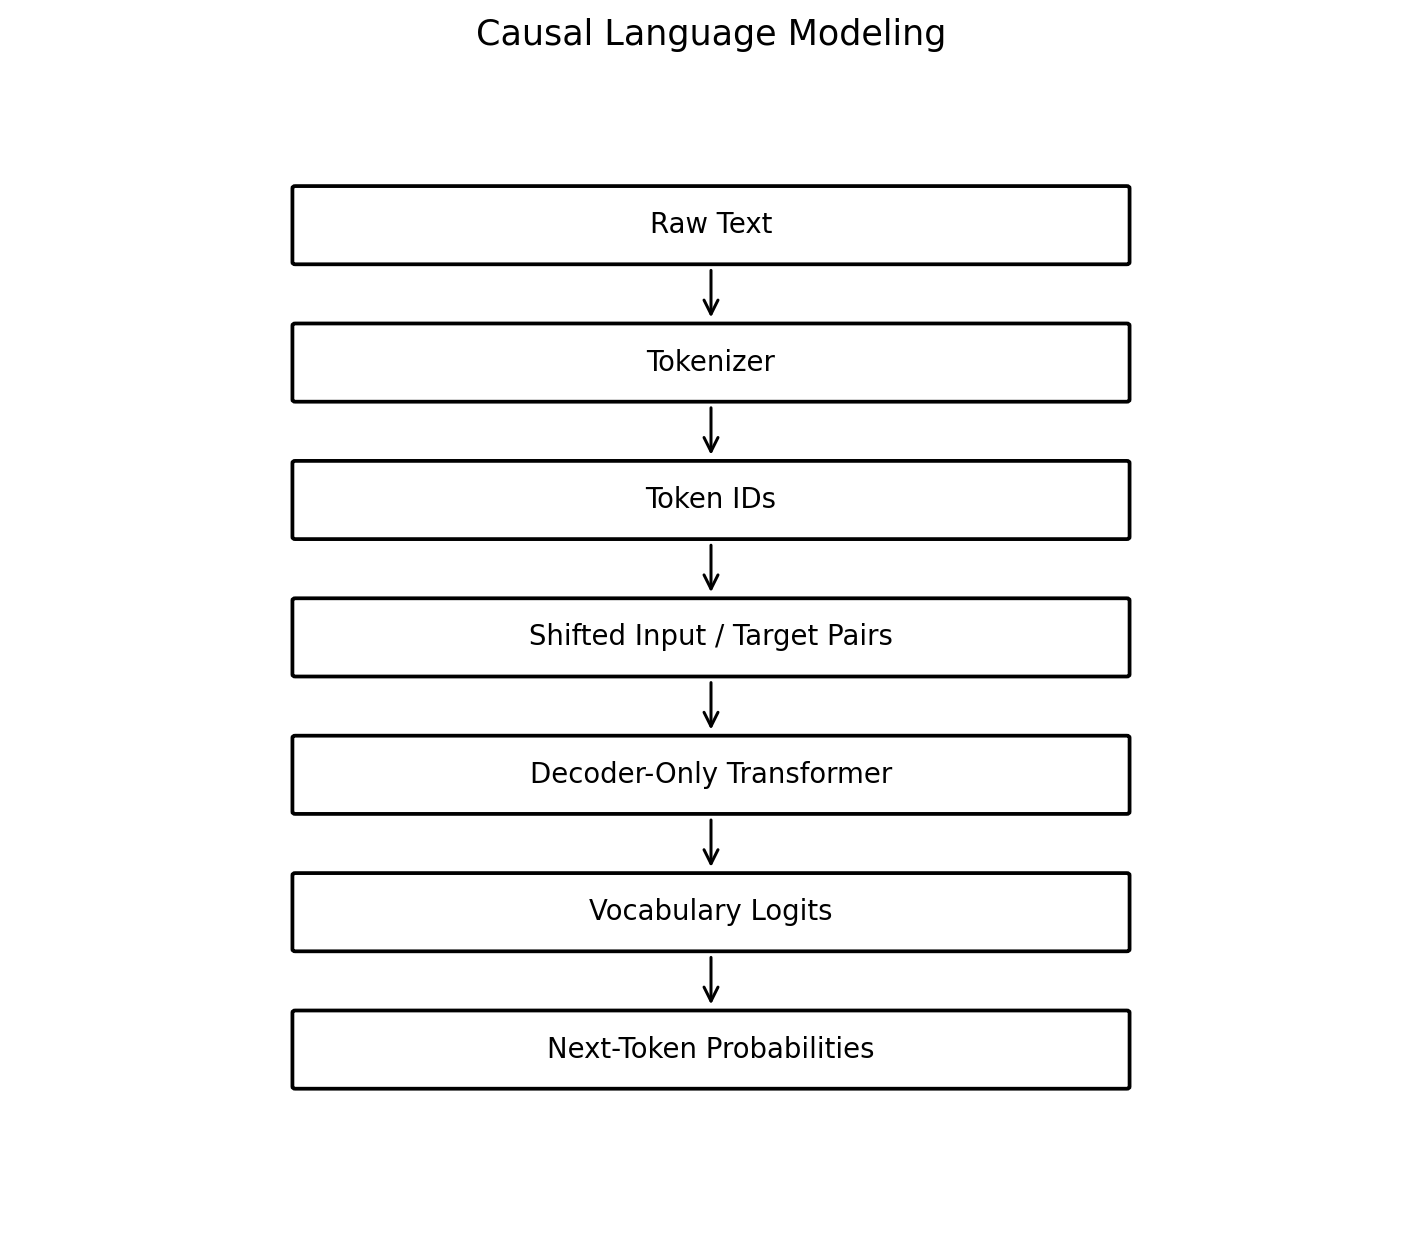

## Learning Objectives

By the end of this notebook, you should be able to:

- explain next-token prediction mathematically,
- distinguish causal language modeling from generic Transformer architecture,
- build a character vocabulary and tokenizer from scratch,
- create shifted input-target training sequences,
- explain context length, batch size, and tensor dimensions,
- implement masked self-attention, multi-head attention, feed-forward layers, residual connections, and layer normalization,
- assemble a small GPT-style decoder-only model,
- train the model with cross-entropy loss,
- calculate perplexity,
- generate text using greedy, temperature, and top-k sampling,
- identify the limitations of a small educational GPT model.

## 1. What Is Causal Language Modeling?

A causal language model predicts the next token using only the tokens that appear before it.

For a sequence $x_1, x_2, \ldots, x_T$, the model factorizes the sequence probability as

$$
P(x_1, x_2, \ldots, x_T)
= \prod_{t=1}^{T} P(x_t \mid x_1, \ldots, x_{t-1}).
$$

The word **causal** means the model is not allowed to inspect future tokens while predicting the current target.

### A Tiny Manual Example

Consider the sentence:

> `the cat sat on the mat`

The learning task can be viewed progressively:

| Context | Target next token |
|---|---|
| `the` | `cat` |
| `the cat` | `sat` |
| `the cat sat` | `on` |
| `the cat sat on` | `the` |
| `the cat sat on the` | `mat` |

A single training sequence therefore contains multiple next-token prediction problems.

## 2. Import the Required Libraries

The early sections use plain Python to make each transformation visible. PyTorch is introduced only when tensor operations and the neural model are required.

In [1]:
import math
import random
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

print("PyTorch version:")
print(torch.__version__)

print()
print("CUDA available:")
print(torch.cuda.is_available())

PyTorch version:
2.11.0+cpu

CUDA available:
False


## 3. Reproducibility and Device

A fixed random seed makes the educational experiment easier to reproduce. If a GPU is available, PyTorch can use it automatically.

In [2]:
SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Selected device:")
print(device)

Selected device:
cpu


## 4. Load Tiny Shakespeare

Tiny Shakespeare is a compact public-domain text corpus commonly used for character-level language-model demonstrations. It is small enough for an educational notebook while still containing enough structure for the model to learn patterns.

The notebook downloads the file only if it is not already present in the local `data/` folder.

In [3]:
data_directory = Path("data")
data_directory.mkdir(exist_ok=True)

data_file = data_directory / "tiny_shakespeare.txt"

data_url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

if not data_file.exists():
    print("Downloading Tiny Shakespeare...")
    urllib.request.urlretrieve(data_url, data_file)

text = data_file.read_text(encoding="utf-8")

print("Dataset object type:")
print(type(text))

print()
print("Total number of characters:")
print(len(text))

print()
print("First 500 characters:")
print(text[:500])

Dataset object type:
<class 'str'>

Total number of characters:
1115394

First 500 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## 5. Character-Level Tokenization From Scratch

Modern LLMs usually rely on subword or byte-level tokenizers. We begin with characters because the complete vocabulary can be inspected directly and the encode/decode process is easy to verify.

In [4]:
unique_characters = sorted(set(text))

vocabulary_size = len(unique_characters)

print("Vocabulary:")
print(unique_characters)

print()
print("Vocabulary size:")
print(vocabulary_size)

Vocabulary:
['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

Vocabulary size:
65


### Build the Character-to-Integer Mapping

Each character receives one integer vocabulary ID.

In [5]:
character_to_integer = {}

for index, character in enumerate(unique_characters):
    character_to_integer[character] = index

print("First 20 character-to-integer mappings:")

for character in unique_characters[:20]:
    print(repr(character), "->", character_to_integer[character])

First 20 character-to-integer mappings:
'\n' -> 0
' ' -> 1
'!' -> 2
'$' -> 3
'&' -> 4
"'" -> 5
',' -> 6
'-' -> 7
'.' -> 8
'3' -> 9
':' -> 10
';' -> 11
'?' -> 12
'A' -> 13
'B' -> 14
'C' -> 15
'D' -> 16
'E' -> 17
'F' -> 18
'G' -> 19


### Build the Reverse Mapping

Decoding requires the reverse relationship from token ID back to character.

In [6]:
integer_to_character = {}

for index, character in enumerate(unique_characters):
    integer_to_character[index] = character

print("First 20 integer-to-character mappings:")

for index in range(min(20, vocabulary_size)):
    print(index, "->", repr(integer_to_character[index]))

First 20 integer-to-character mappings:
0 -> '\n'
1 -> ' '
2 -> '!'
3 -> '$'
4 -> '&'
5 -> "'"
6 -> ','
7 -> '-'
8 -> '.'
9 -> '3'
10 -> ':'
11 -> ';'
12 -> '?'
13 -> 'A'
14 -> 'B'
15 -> 'C'
16 -> 'D'
17 -> 'E'
18 -> 'F'
19 -> 'G'


### Encode a Small Example Manually

The explicit loop below shows that tokenization is a mapping operation, not a mysterious neural-network step.

In [7]:
example_text = "Hello"

encoded_example = []

for character in example_text:
    token_id = character_to_integer[character]
    encoded_example.append(token_id)

print("Original text:")
print(example_text)

print()
print("Encoded token IDs:")
print(encoded_example)

Original text:
Hello

Encoded token IDs:
[20, 43, 50, 50, 53]


### Decode the Example Manually

In [8]:
decoded_characters = []

for token_id in encoded_example:
    character = integer_to_character[token_id]
    decoded_characters.append(character)

decoded_example = "".join(decoded_characters)

print("Decoded text:")
print(decoded_example)

Decoded text:
Hello


### Wrap the Logic in Reusable Functions

Only after verifying the mechanism manually do we package it into two helper functions.

In [9]:
def encode(text_input):
    token_ids = []

    for character in text_input:
        token_id = character_to_integer[character]
        token_ids.append(token_id)

    return token_ids


def decode(token_ids):
    characters = []

    for token_id in token_ids:
        character = integer_to_character[int(token_id)]
        characters.append(character)

    return "".join(characters)

sample_text = "Language model"
sample_ids = encode(sample_text)
sample_reconstruction = decode(sample_ids)

print("Original:")
print(sample_text)

print()
print("Token IDs:")
print(sample_ids)

print()
print("Decoded:")
print(sample_reconstruction)

Original:
Language model

Token IDs:
[24, 39, 52, 45, 59, 39, 45, 43, 1, 51, 53, 42, 43, 50]

Decoded:
Language model


## 6. Why Real LLMs Usually Use Subword Tokenization

Character tokenization keeps the vocabulary very small, but it creates long sequences. Word-level tokenization shortens sequences but produces a very large vocabulary and struggles with unseen words.

Modern LLM tokenizers usually compromise with subword or byte-level methods such as BPE, WordPiece, SentencePiece, or byte-level BPE.

Conceptually:

`unbelievable` → `un` + `believ` + `able`

This creates a trade-off between **vocabulary size** and **sequence length**.

## 7. Convert the Complete Corpus to Token IDs

In [10]:
encoded_text = encode(text)

data = torch.tensor(encoded_text, dtype=torch.long)

print("Tensor type:")
print(type(data))

print()
print("Tensor shape:")
print(data.shape)

print()
print("Tensor dtype:")
print(data.dtype)

print()
print("First 40 token IDs:")
print(data[:40])

print()
print("Decoded first 40 tokens:")
print(decode(data[:40].tolist()))

Tensor type:
<class 'torch.Tensor'>

Tensor shape:
torch.Size([1115394])

Tensor dtype:
torch.int64

First 40 token IDs:
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56])

Decoded first 40 tokens:
First Citizen:
Before we proceed any fur


## 8. Training and Validation Split

Training data update the model parameters. Validation data are not used for gradient updates; they are used to monitor generalization during development.

In [11]:
train_fraction = 0.90

split_index = int(train_fraction * len(data))

train_data = data[:split_index]
validation_data = data[split_index:]

print("Training tokens:")
print(len(train_data))

print()
print("Validation tokens:")
print(len(validation_data))

Training tokens:
1003854

Validation tokens:
111540


## 9. Context Length and Shifted Targets

Suppose the context length is 8. One training block contains 8 input tokens and the target is the same sequence shifted one position to the left.

This allows the model to learn several next-token predictions in one forward pass.

In [12]:
block_size = 8

example_block = train_data[: block_size + 1]

x_example = example_block[:-1]
y_example = example_block[1:]

print("Input token IDs:")
print(x_example)

print()
print("Target token IDs:")
print(y_example)

print()
print("Input text:")
print(decode(x_example.tolist()))

print()
print("Target text:")
print(decode(y_example.tolist()))

Input token IDs:
tensor([18, 47, 56, 57, 58,  1, 15, 47])

Target token IDs:
tensor([47, 56, 57, 58,  1, 15, 47, 58])

Input text:
First Ci

Target text:
irst Cit


### Inspect Every Prediction Inside the Block

In [13]:
for position in range(block_size):
    context = x_example[: position + 1]
    target = y_example[position]

    print("Context:", repr(decode(context.tolist())))
    print("Target:", repr(decode([int(target)])))
    print()

Context: 'F'
Target: 'i'

Context: 'Fi'
Target: 'r'

Context: 'Fir'
Target: 's'

Context: 'Firs'
Target: 't'

Context: 'First'
Target: ' '

Context: 'First '
Target: 'C'

Context: 'First C'
Target: 'i'

Context: 'First Ci'
Target: 't'



## 10. Build Mini-Batches

A batch contains several independent context windows so the model can process them in parallel.

In [14]:
batch_size = 32
block_size = 64


def get_batch(split):
    if split == "train":
        source_data = train_data
    else:
        source_data = validation_data

    maximum_start = len(source_data) - block_size - 1

    start_indices = torch.randint(
        low=0,
        high=maximum_start,
        size=(batch_size,)
    )

    input_sequences = []
    target_sequences = []

    for start_index in start_indices:
        start_index = int(start_index)

        input_sequence = source_data[start_index : start_index + block_size]
        target_sequence = source_data[start_index + 1 : start_index + block_size + 1]

        input_sequences.append(input_sequence)
        target_sequences.append(target_sequence)

    x = torch.stack(input_sequences)
    y = torch.stack(target_sequences)

    x = x.to(device)
    y = y.to(device)

    return x, y

x_batch, y_batch = get_batch("train")

print("Input batch shape:")
print(x_batch.shape)

print()
print("Target batch shape:")
print(y_batch.shape)

Input batch shape:
torch.Size([32, 64])

Target batch shape:
torch.Size([32, 64])


The shape is:

`(batch_size, context_length)`

Each row is one sequence and each column is one token position.

## 11. Token and Positional Embeddings

A token ID is only an integer label. The embedding table converts each token ID into a dense learned vector. A separate positional embedding tells the decoder where each token appears within the context window.

In [15]:
embedding_dimension = 128

token_embedding_demo = nn.Embedding(
    vocabulary_size,
    embedding_dimension
).to(device)

position_embedding_demo = nn.Embedding(
    block_size,
    embedding_dimension
).to(device)

small_input = x_batch[:2]

B, T = small_input.shape

sample_token_embeddings = token_embedding_demo(small_input)
position_indices = torch.arange(T, device=device)
sample_position_embeddings = position_embedding_demo(position_indices)

print("Token embedding shape:")
print(sample_token_embeddings.shape)

print()
print("Position embedding shape:")
print(sample_position_embeddings.shape)

Token embedding shape:
torch.Size([2, 64, 128])

Position embedding shape:
torch.Size([64, 128])


## 12. Causal Self-Attention

A GPT-style model must prevent a position from attending to future positions.

For four tokens, the visibility pattern is:

```text
1 0 0 0
1 1 0 0
1 1 1 0
1 1 1 1
```

The lower-triangular mask enforces this constraint.

In [16]:
mask_demo = torch.tril(torch.ones(8, 8))

print("Causal mask:")
print(mask_demo)

Causal mask:
tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])


## 13. Implement One Causal Self-Attention Head

For each token representation $x$, self-attention creates a query, key, and value:

$$Q = XW_Q, \quad K = XW_K, \quad V = XW_V.$$

Scaled dot-product attention is:

$$
\text{Attention}(Q,K,V)
=
\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

In [17]:
class CausalSelfAttentionHead(nn.Module):

    def __init__(self, embedding_dimension, head_size, block_size, dropout_probability):
        super().__init__()

        self.key = nn.Linear(embedding_dimension, head_size, bias=False)
        self.query = nn.Linear(embedding_dimension, head_size, bias=False)
        self.value = nn.Linear(embedding_dimension, head_size, bias=False)

        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(block_size, block_size))
        )

        self.dropout = nn.Dropout(dropout_probability)

    def forward(self, x):
        B, T, C = x.shape

        keys = self.key(x)
        queries = self.query(x)
        values = self.value(x)

        attention_scores = queries @ keys.transpose(-2, -1)
        attention_scores = attention_scores * (keys.shape[-1] ** -0.5)

        visible_mask = self.causal_mask[:T, :T]
        attention_scores = attention_scores.masked_fill(visible_mask == 0, float("-inf"))

        attention_weights = F.softmax(attention_scores, dim=-1)
        attention_weights = self.dropout(attention_weights)

        output = attention_weights @ values

        return output

## 14. Multi-Head Attention

Multiple attention heads learn different projections of the same sequence. Their outputs are concatenated and projected back to the model embedding dimension.

In [18]:
class MultiHeadCausalAttention(nn.Module):

    def __init__(self, number_of_heads, embedding_dimension, block_size, dropout_probability):
        super().__init__()

        head_size = embedding_dimension // number_of_heads

        heads = []

        for _ in range(number_of_heads):
            head = CausalSelfAttentionHead(
                embedding_dimension,
                head_size,
                block_size,
                dropout_probability
            )

            heads.append(head)

        self.heads = nn.ModuleList(heads)

        self.projection = nn.Linear(
            embedding_dimension,
            embedding_dimension
        )

        self.dropout = nn.Dropout(dropout_probability)

    def forward(self, x):
        head_outputs = []

        for head in self.heads:
            head_output = head(x)
            head_outputs.append(head_output)

        combined = torch.cat(head_outputs, dim=-1)
        projected = self.projection(combined)
        projected = self.dropout(projected)

        return projected

## 15. Position-Wise Feed-Forward Network

Attention mixes information across token positions. The feed-forward network then transforms each position independently through a nonlinear hidden layer.

In [19]:
class FeedForward(nn.Module):

    def __init__(self, embedding_dimension, dropout_probability):
        super().__init__()

        hidden_dimension = 4 * embedding_dimension

        self.network = nn.Sequential(
            nn.Linear(embedding_dimension, hidden_dimension),
            nn.GELU(),
            nn.Linear(hidden_dimension, embedding_dimension),
            nn.Dropout(dropout_probability)
        )

    def forward(self, x):
        return self.network(x)

## 16. Transformer Decoder Block

The block uses a pre-normalization design:

1. LayerNorm
2. masked multi-head self-attention
3. residual addition
4. LayerNorm
5. feed-forward network
6. residual addition

Residual connections help gradients flow through deeper networks.

In [20]:
class TransformerDecoderBlock(nn.Module):

    def __init__(self, embedding_dimension, number_of_heads, block_size, dropout_probability):
        super().__init__()

        self.layer_norm_1 = nn.LayerNorm(embedding_dimension)
        self.attention = MultiHeadCausalAttention(
            number_of_heads,
            embedding_dimension,
            block_size,
            dropout_probability
        )

        self.layer_norm_2 = nn.LayerNorm(embedding_dimension)
        self.feed_forward = FeedForward(
            embedding_dimension,
            dropout_probability
        )

    def forward(self, x):
        attention_input = self.layer_norm_1(x)
        attention_output = self.attention(attention_input)
        x = x + attention_output

        feed_forward_input = self.layer_norm_2(x)
        feed_forward_output = self.feed_forward(feed_forward_input)
        x = x + feed_forward_output

        return x

## 17. Assemble a Mini GPT

The model combines:

- token embeddings,
- positional embeddings,
- repeated decoder blocks,
- final layer normalization,
- language-model head that produces one logit per vocabulary token.

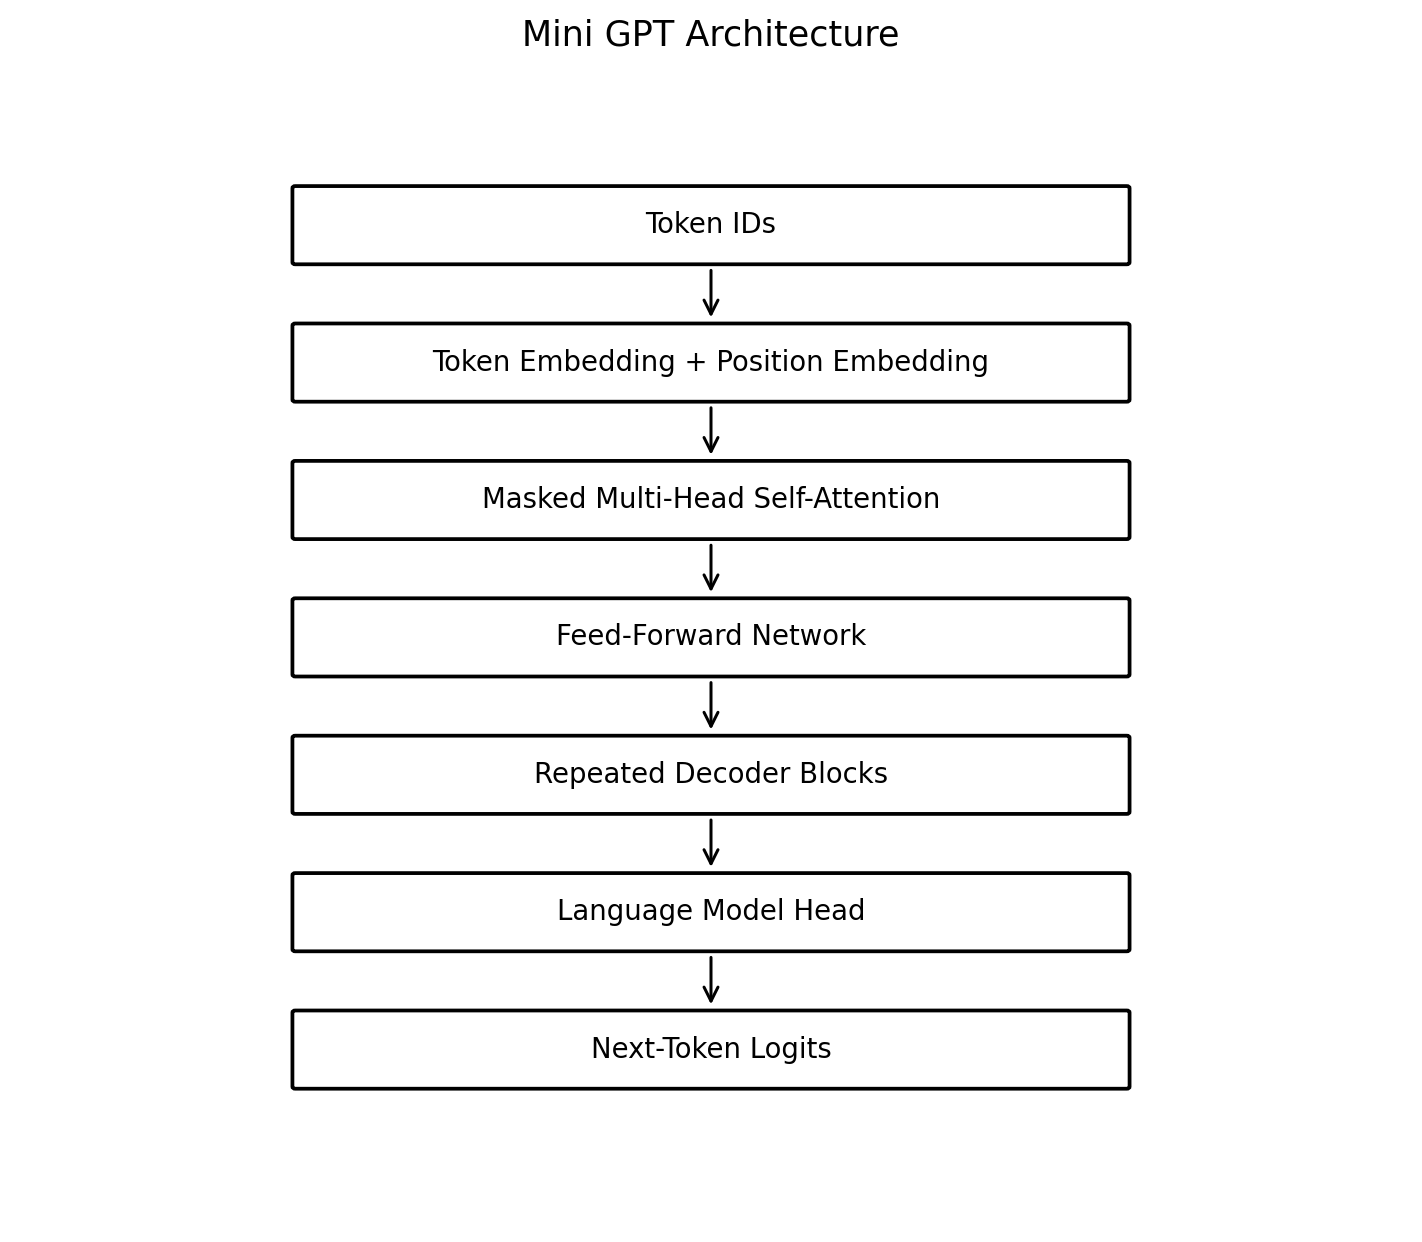

In [21]:
class MiniGPT(nn.Module):

    def __init__(
        self,
        vocabulary_size,
        block_size,
        embedding_dimension=128,
        number_of_heads=4,
        number_of_layers=4,
        dropout_probability=0.1
    ):
        super().__init__()

        self.block_size = block_size

        self.token_embedding = nn.Embedding(
            vocabulary_size,
            embedding_dimension
        )

        self.position_embedding = nn.Embedding(
            block_size,
            embedding_dimension
        )

        blocks = []

        for _ in range(number_of_layers):
            block = TransformerDecoderBlock(
                embedding_dimension,
                number_of_heads,
                block_size,
                dropout_probability
            )

            blocks.append(block)

        self.blocks = nn.Sequential(*blocks)
        self.final_layer_norm = nn.LayerNorm(embedding_dimension)
        self.language_model_head = nn.Linear(
            embedding_dimension,
            vocabulary_size
        )

    def forward(self, token_ids, targets=None):
        B, T = token_ids.shape

        token_embeddings = self.token_embedding(token_ids)

        position_indices = torch.arange(T, device=token_ids.device)
        position_embeddings = self.position_embedding(position_indices)

        x = token_embeddings + position_embeddings
        x = self.blocks(x)
        x = self.final_layer_norm(x)

        logits = self.language_model_head(x)

        loss = None

        if targets is not None:
            B, T, V = logits.shape

            logits_for_loss = logits.reshape(B * T, V)
            targets_for_loss = targets.reshape(B * T)

            loss = F.cross_entropy(
                logits_for_loss,
                targets_for_loss
            )

        return logits, loss

## 18. Instantiate and Inspect the Model

In [22]:
model = MiniGPT(
    vocabulary_size=vocabulary_size,
    block_size=block_size,
    embedding_dimension=128,
    number_of_heads=4,
    number_of_layers=4,
    dropout_probability=0.1
)

model = model.to(device)

number_of_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(model)

print()
print("Total number of parameters:")
print(f"{number_of_parameters:,}")

MiniGPT(
  (token_embedding): Embedding(65, 128)
  (position_embedding): Embedding(64, 128)
  (blocks): Sequential(
    (0): TransformerDecoderBlock(
      (layer_norm_1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attention): MultiHeadCausalAttention(
        (heads): ModuleList(
          (0-3): 4 x CausalSelfAttentionHead(
            (key): Linear(in_features=128, out_features=32, bias=False)
            (query): Linear(in_features=128, out_features=32, bias=False)
            (value): Linear(in_features=128, out_features=32, bias=False)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        (projection): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (layer_norm_2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (feed_forward): FeedForward(
        (network): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GE

## 19. Inspect Logits and Cross-Entropy Loss

For a vocabulary of size `V`, each token position produces `V` logits. Softmax converts these logits into a probability distribution over possible next tokens.

In [23]:
x_batch, y_batch = get_batch("train")

logits, loss = model(x_batch, y_batch)

print("Logits shape:")
print(logits.shape)

print()
print("Loss:")
print(float(loss))

Logits shape:
torch.Size([32, 64, 65])

Loss:
4.335183620452881


/tmp/ipykernel_800/2573119674.py:10: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(float(loss))


### Inspect the Probability Distribution for One Position

In [24]:
first_sequence_logits = logits[0]
first_position_logits = first_sequence_logits[0]

first_position_probabilities = F.softmax(
    first_position_logits,
    dim=-1
)

predicted_token_id = int(torch.argmax(first_position_probabilities))

print("Probability vector shape:")
print(first_position_probabilities.shape)

print()
print("Predicted token ID:")
print(predicted_token_id)

print()
print("Predicted character:")
print(repr(decode([predicted_token_id])))

Probability vector shape:
torch.Size([65])

Predicted token ID:
39

Predicted character:
'a'


## 20. Evaluate Average Loss Before Training

In [25]:
@torch.no_grad()
def estimate_loss(model, evaluation_batches=20):
    model.eval()

    results = {}

    for split in ["train", "validation"]:
        losses = []

        for _ in range(evaluation_batches):
            x, y = get_batch(split)
            _, loss = model(x, y)
            losses.append(float(loss))

        average_loss = sum(losses) / len(losses)
        results[split] = average_loss

    model.train()

    return results

initial_losses = estimate_loss(model)

print("Initial training loss:")
print(initial_losses["train"])

print()
print("Initial validation loss:")
print(initial_losses["validation"])

Initial training loss:
4.304932022094727

Initial validation loss:
4.31413779258728


## 21. Generate Text Before Training

An untrained model has random weights, so its output should look mostly random. Comparing pre-training and post-training samples makes the effect of learning visible.

In [26]:
@torch.no_grad()
def generate_tokens(
    model,
    starting_token_ids,
    number_of_new_tokens,
    temperature=1.0,
    top_k=None,
    greedy=False
):
    generated = starting_token_ids.clone()

    for _ in range(number_of_new_tokens):
        model_input = generated[:, -model.block_size:]

        logits, _ = model(model_input)

        next_token_logits = logits[:, -1, :]

        if greedy:
            next_token = torch.argmax(
                next_token_logits,
                dim=-1,
                keepdim=True
            )
        else:
            next_token_logits = next_token_logits / temperature

            if top_k is not None:
                top_values, _ = torch.topk(next_token_logits, top_k)
                cutoff = top_values[:, -1].unsqueeze(-1)

                next_token_logits = torch.where(
                    next_token_logits < cutoff,
                    torch.full_like(next_token_logits, float("-inf")),
                    next_token_logits
                )

            probabilities = F.softmax(
                next_token_logits,
                dim=-1
            )

            next_token = torch.multinomial(
                probabilities,
                num_samples=1
            )

        generated = torch.cat(
            [generated, next_token],
            dim=1
        )

    return generated

start_text = "ROMEO:"
start_ids = torch.tensor([encode(start_text)], dtype=torch.long).to(device)

untrained_output = generate_tokens(
    model,
    start_ids,
    number_of_new_tokens=200,
    temperature=1.0
)

print(decode(untrained_output[0].tolist()))

ROMEO:Vk-l&ZntRf$Byv &3idR;YNBfGun!:dkKb,xdltfNgsKGBeplubjJMuRnU,.ie:ErSgonBoXd'eb&wU?,Lf,krNcMfejqwuyVqcLhc.Dga&LXrXIA-u3ubNAfYX, mceyPD'3V,-uB?CcEnEkoSpGJ:H?NF.bqaiKCuG,Do!SlXNFl'xgo-aClqXxW&licEAcCTQg
ck


## 22. Train the Mini GPT

The training loop is intentionally explicit. Each iteration:

1. samples a mini-batch,
2. performs a forward pass,
3. computes cross-entropy loss,
4. clears old gradients,
5. performs backpropagation,
6. updates the model parameters.

The default iteration count is intentionally moderate so the notebook remains practical. Increase it if more compute is available.

In [27]:
learning_rate = 3e-4
training_steps = 1200
report_every = 200

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate
)

history_steps = []
history_train_loss = []
history_validation_loss = []

for step in range(training_steps + 1):

    if step % report_every == 0:
        losses = estimate_loss(model)

        history_steps.append(step)
        history_train_loss.append(losses["train"])
        history_validation_loss.append(losses["validation"])

        print(
            "Step:", step,
            "| Train loss:", round(losses["train"], 4),
            "| Validation loss:", round(losses["validation"], 4)
        )

    x_batch, y_batch = get_batch("train")

    logits, loss = model(x_batch, y_batch)

    optimizer.zero_grad(set_to_none=True)

    loss.backward()

    optimizer.step()

Step: 0 | Train loss: 4.3045 | Validation loss: 4.3151
Step: 200 | Train loss: 2.5008 | Validation loss: 2.5061
Step: 400 | Train loss: 2.3389 | Validation loss: 2.3582
Step: 600 | Train loss: 2.2089 | Validation loss: 2.2337
Step: 800 | Train loss: 2.0925 | Validation loss: 2.144
Step: 1000 | Train loss: 2.0349 | Validation loss: 2.0691
Step: 1200 | Train loss: 1.9551 | Validation loss: 2.0098


## 23. Plot Training and Validation Loss

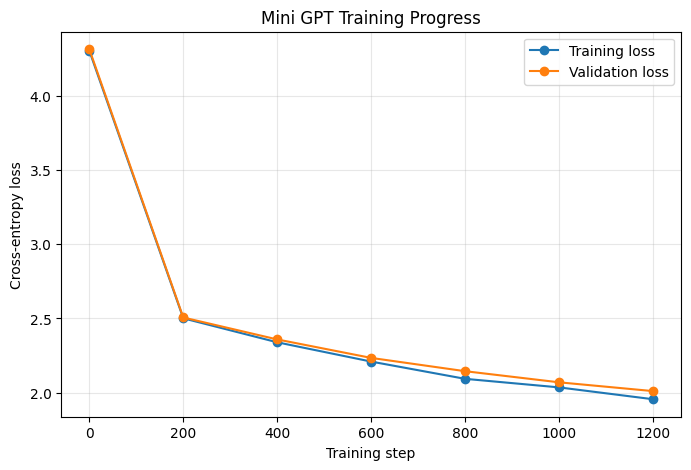

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(history_steps, history_train_loss, marker="o", label="Training loss")
plt.plot(history_steps, history_validation_loss, marker="o", label="Validation loss")

plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Mini GPT Training Progress")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretation

A useful training curve should show a substantial reduction from the initial loss. If training loss continues falling while validation loss rises, the model may be overfitting the small corpus.

## 24. Perplexity

Perplexity is commonly used for autoregressive language modeling. If the average cross-entropy is $L$, perplexity is

$$
	ext{Perplexity} = e^L.
$$

Lower perplexity generally means the model assigns more probability to the observed sequence.

In [29]:
final_losses = estimate_loss(model, evaluation_batches=50)

validation_loss = final_losses["validation"]
validation_perplexity = math.exp(validation_loss)

print("Final validation loss:")
print(round(validation_loss, 4))

print()
print("Validation perplexity:")
print(round(validation_perplexity, 4))

Final validation loss:
2.0054

Validation perplexity:
7.4289


## 25. Generate Text After Training

In [30]:
trained_output = generate_tokens(
    model,
    start_ids,
    number_of_new_tokens=500,
    temperature=0.8,
    top_k=20
)

print(decode(trained_output[0].tolist()))

ROMEO:
Whe mere seave a cond wers the to hat let,
And to live of best aur of it that ye so so my
I be be ory, your le have as count ther,
And astar the fur hearst of reespors too--
What so, hem so the hing tong chea gor but with
The sutser ity that count.

ISAPUTENTAUS:
That y dneou thy a bet with there of tee on warce
Of be thertert and, thy broghter in theis houst blize
that in seme, will destsse it the he futtent grower!

ARINIUS:
I wit blay will leart is her his not me tooke,
An, gur the have tund


## 26. Compare Decoding Strategies

The trained network produces logits. Decoding determines how those logits are converted into the next generated token.

- **Greedy decoding:** always choose the highest-probability token.
- **Temperature sampling:** adjust how sharp or flat the distribution is.
- **Top-k sampling:** sample only from the `k` highest-logit candidates.

In [31]:
print("GREEDY DECODING")
print("-" * 60)

greedy_output = generate_tokens(
    model,
    start_ids,
    number_of_new_tokens=250,
    greedy=True
)

print(decode(greedy_output[0].tolist()))

GREEDY DECODING
------------------------------------------------------------
ROMEO:
I he the the the he the the son the the the the the the the the the the the the thee the the the sour the the the the the seare
The the the the the the the hee he the the sould the the the he the the the he the the the the the the the shee heave
The


In [32]:
print("LOW TEMPERATURE = 0.5")
print("-" * 60)

low_temperature_output = generate_tokens(
    model,
    start_ids,
    number_of_new_tokens=250,
    temperature=0.5,
    top_k=20
)

print(decode(low_temperature_output[0].tolist()))

LOW TEMPERATURE = 0.5
------------------------------------------------------------
ROMEO:
I shat in thy sour the sing the so the the he hime the hey deake here hourd dise bet.

MARIO:
The the sad the to may hath the my or shan the priste,
Thou his havod sing and an shous and and the the as fromest to they shat
sould man do hist by seand 


In [33]:
print("HIGHER TEMPERATURE = 1.2")
print("-" * 60)

higher_temperature_output = generate_tokens(
    model,
    start_ids,
    number_of_new_tokens=250,
    temperature=1.2,
    top_k=20
)

print(decode(higher_temperature_output[0].tolist()))

HIGHER TEMPERATURE = 1.2
------------------------------------------------------------
ROMEO:
Oungs me engt'llo themie conger
Cend a mote a mallth ungate,
Whee prousd like, wef he hiry shold b'd thaid,
FLed mirsich's whrous chanky fon thruch

Theas welt one cue.

DUKE
IRCK:
HEP:ARd,
Ssod cam they lasup miog; tine; woreel,
I ins, whei, an wa 


## 27. What This Mini GPT Teaches — and What It Does Not

### What it demonstrates

- autoregressive next-token learning,
- shifted training targets,
- learned token and positional embeddings,
- causal masking,
- multi-head self-attention,
- residual decoder blocks,
- language-model logits,
- cross-entropy training,
- perplexity,
- autoregressive text generation.

### Important limitations

- character-level tokenization creates long sequences,
- the corpus is tiny compared with modern LLM pretraining corpora,
- the parameter count is tiny,
- the context window is very short,
- the model has little factual or world knowledge,
- it has not been instruction-tuned,
- it has no preference alignment,
- it can produce incoherent or memorized-looking text,
- it does not represent the distributed training infrastructure of modern LLMs.

## 28. Connection to the Next Notebook

This notebook built the central mechanism ourselves. The next notebook moves to a **pretrained causal language model** and inspects the hidden steps that high-level libraries perform during tokenization, inference, probability calculation, and decoding.

## Key Takeaways

1. GPT-style language models learn by predicting the next token from previous context.
2. The training target is produced by shifting the input sequence one token forward.
3. Causal masking prevents information leakage from future tokens.
4. Decoder blocks combine masked self-attention, feed-forward transformations, normalization, and residual connections.
5. The language-model head converts hidden representations into vocabulary logits.
6. Cross-entropy measures prediction quality; perplexity is an interpretable transformation of this loss.
7. Generation quality depends not only on the model but also on the decoding strategy.
8. Building a small GPT from scratch makes the behavior of pretrained LLM libraries easier to understand.